# notebook for exploring relationship between F_S and MHT

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd
from scipy import signal, stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import palettable.colorbrewer as cb 

from statsmodels.tsa.stattools import ccf
from PIL import Image
import io

from process_raw_data import process_data, decimal_year_to_datetime
from stats_plots import zero_lag_corr_hf_mht, compute_n_eff_and_r_crit, parse_lat_label, plot_hovmöller, plot_lead_lag_single_region

# open data and process

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}-{fmt(lat2)}")

ds["time"] = decimal_year_to_datetime(ds.time.values)

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")
mht_raw_anom = process_data(mht_mean, anomalies=True)
mht_filtered = process_data(mht_mean)

lats = lats[1:]  # drop 65
lat_labels = lat_labels#[1:]  # drop 65
n_lats = len(lats)

# # surface heat flux

hf = ds.qnet.dropna(dim="time", how="any")
hf_mean = hf.mean(dim="posterior_samples")
hf_filtered = process_data(hf_mean)

## heat transport convergence

htc = ds.htc.dropna(dim="time", how="any")
htc_mean = htc.mean(dim="posterior_samples")
htc_filtered = process_data(htc_mean)


regions = np.arange(hf_filtered.sizes["number_regions"])

region_bounds = []
print(region_labels)
for i, label in enumerate(region_labels):
    lo, hi = (parse_lat_label(b) for b in label.split("-", 1))
    region_bounds.append((lo, hi))
    
region_info = {"idx": regions, "labels": region_labels, "bounds": region_bounds}

['65°N-60°N', '60°N-55°N', '55°N-45°N', '45°N-35°N', '35°N-26°N', '26°N-16°N', '16°N-5°N', '5°N-5°S', '5°S-11°S', '11°S-25°S', '25°S-35°S']


## colors for plotting

In [3]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})

def make_diverging_cmap(palette, n=40):
    colors_ = palette.mpl_colors
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_diverging', colors_)
    return mcolors.ListedColormap(cmap(np.linspace(0, 1, n)))

cmap_corr = make_diverging_cmap(cb.diverging.RdBu_11_r)      # correlation: red-blue (conventional)
cmap_mht  = make_diverging_cmap(cb.diverging.PuOr_11)         # MHT anomalies
cmap_hf   = make_diverging_cmap(cb.diverging.BrBG_11_r)         # HF anomalies
cmap_htc = make_diverging_cmap(cb.diverging.PiYG_10_r)



## significance testing to get r crit for both

In [4]:
time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
 
# for mht:
n_effs_mht, r_crits_mht, its_mht = compute_n_eff_and_r_crit(
    mht_filtered,
    coord_values=lats,
    coord_labels=lat_labels,
    dim="lat",
    del_t=del_t,
    time_unit=time_unit,
    plateau_values=[45, 35],
    plot=False
)
# for hf
n_effs_hf, r_crits_hf, its_hf = compute_n_eff_and_r_crit(
    hf_filtered,
    coord_values=region_info["idx"],
    coord_labels=region_info["labels"],
    dim="number_regions",
    del_t=del_t,
    time_unit=time_unit,
    plot=False
)

n_effs_htc, r_crits_htc, its_htc = compute_n_eff_and_r_crit(
    htc_filtered,
    coord_values=region_info["idx"],
    coord_labels=region_info["labels"],
    dim="number_regions",
    del_t=del_t,
    time_unit=time_unit,
    plot=False
)

Total number of samples: 66
65.0°N: ITS = 1.65 years, N_eff = 10.0
60.0°N: ITS = 1.92 years, N_eff = 8.6
55.0°N: ITS = 2.87 years, N_eff = 5.8
45.0°N: ITS = 2.02 years, N_eff = 8.2
35.0°N: ITS = 0.75 years, N_eff = 22.1
26.0°N: ITS = 0.72 years, N_eff = 22.8
16.0°N: ITS = 0.73 years, N_eff = 22.5
5.0°N: ITS = 0.75 years, N_eff = 22.1
5.0°S: ITS = 0.75 years, N_eff = 22.1
11.0°S: ITS = 0.73 years, N_eff = 22.7
25.0°S: ITS = 0.40 years, N_eff = 41.3
Total number of samples: 66
65°N-60°N: ITS = 0.79 years, N_eff = 20.8
60°N-55°N: ITS = 1.16 years, N_eff = 14.2
55°N-45°N: ITS = 0.75 years, N_eff = 21.9
45°N-35°N: ITS = 0.74 years, N_eff = 22.2
35°N-26°N: ITS = 0.41 years, N_eff = 40.6
26°N-16°N: ITS = 0.76 years, N_eff = 21.8
16°N-5°N: ITS = 0.74 years, N_eff = 22.4
5°N-5°S: ITS = 0.78 years, N_eff = 21.2
5°S-11°S: ITS = 0.39 years, N_eff = 42.4
11°S-25°S: ITS = 0.78 years, N_eff = 21.2
25°S-35°S: ITS = 0.72 years, N_eff = 23.0
Total number of samples: 66
65°N-60°N: ITS = 1.65 years, N_eff

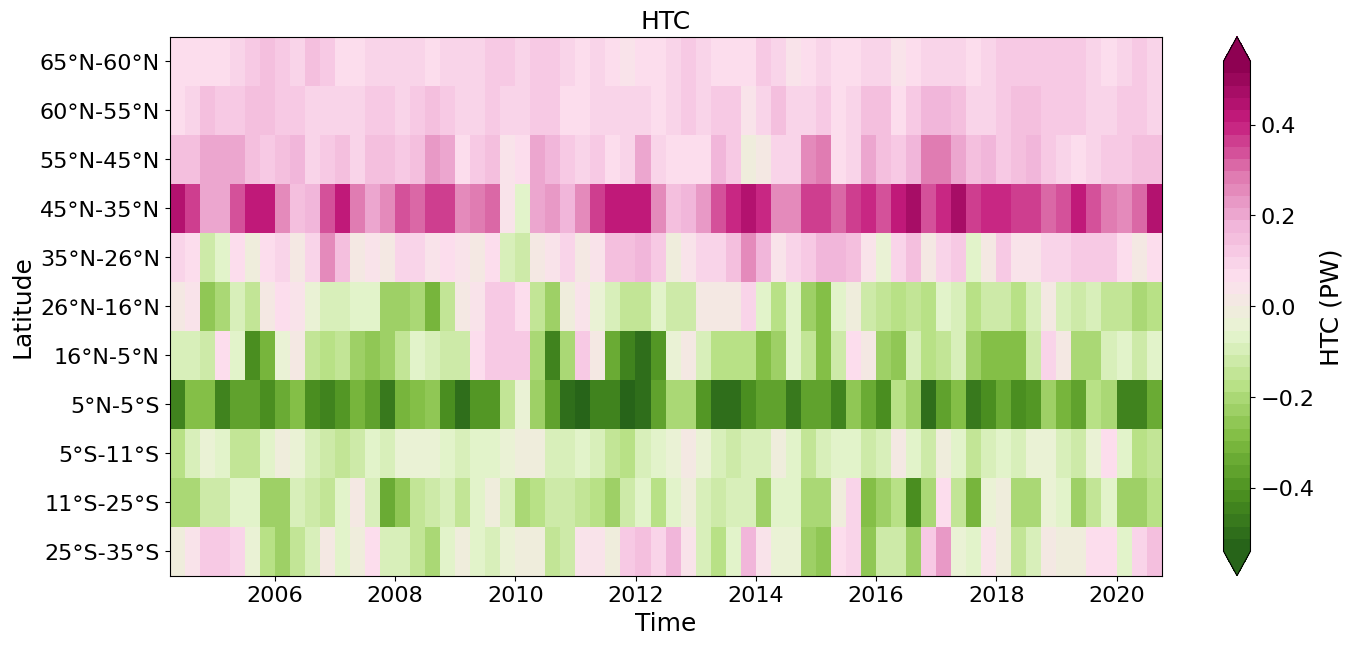

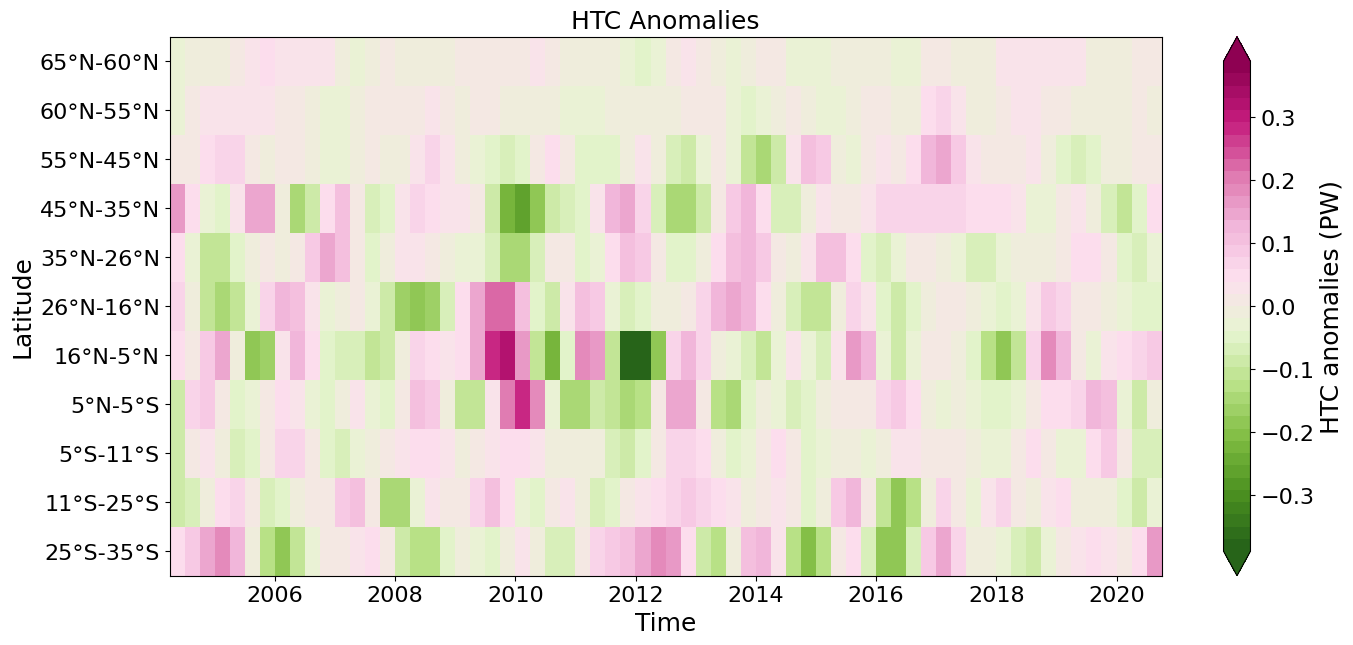

In [5]:
plot_hovmöller(htc_mean, lats=regions, lat_labels=region_labels, anomalies=False, cmap=cmap_htc, data_label="HTC")
plot_hovmöller(htc_filtered, lats=regions, lat_labels=region_labels, anomalies=True, cmap=cmap_htc, data_label="HTC", savefig=True)

# try 0 lag correlation with different hf latitudes


In [6]:
# for i in regions:
#     hf_region = hf_filtered.isel(number_regions=i)
#     region_bounds = region_labels[i].split("-", 1)
#     region_bounds = tuple(parse_lat_label(b) for b in region_bounds)
#     zero_lag_corr_hf_mht(
#         hf_region=hf_region,
#         mht=mht_filtered,
#         region_bounds=region_bounds,
#         dimension="time",
#         lats=lats,
#         lat_labels=lat_labels,
#         plot=True
#     )

In [7]:
# corr_matrix = []

# for i in regions:
#     hf_region = hf_filtered.isel(number_regions=i)
    
#     corr = xr.corr(hf_region, mht_filtered, dim="time")
#     corr_matrix.append(corr.values)


# corr_matrix = np.array(corr_matrix)  # shape: (n_regions, n_mht_lats)
# plot_crosscorr_hf_mht(
#     corr_matrix=corr_matrix,
#     region_info = region_info,
#     lats=lats,
#     lat_labels=lat_labels,
#     cmap=cmap_corr,
#     significance=True,
#     n_effs_hf=n_effs_hf,
#     n_effs_mht=n_effs_mht,
#     title="Cross-correlation: HF regions vs MHT latitudes",
# )


## correlate HF with htc

# zero lag corr hf and htc

In [8]:
n_regions = htc_mean.sizes["number_regions"]
zero_lag_corr = []
for i in range(n_regions):
    x = htc_filtered.isel(number_regions=i).values
    y = hf_filtered.isel(number_regions=i).values
    r, p = stats.pearsonr(x, y)
    zero_lag_corr.append((i, r, p))

for i, r, p in zero_lag_corr:
    print(f"Region {i}: r={r:.2f}, p={p:.3f}")

Region 0: r=0.40, p=0.001
Region 1: r=0.18, p=0.138
Region 2: r=0.53, p=0.000
Region 3: r=0.32, p=0.010
Region 4: r=0.44, p=0.000
Region 5: r=0.29, p=0.020
Region 6: r=0.63, p=0.000
Region 7: r=0.52, p=0.000
Region 8: r=0.43, p=0.000
Region 9: r=0.04, p=0.780
Region 10: r=0.28, p=0.021


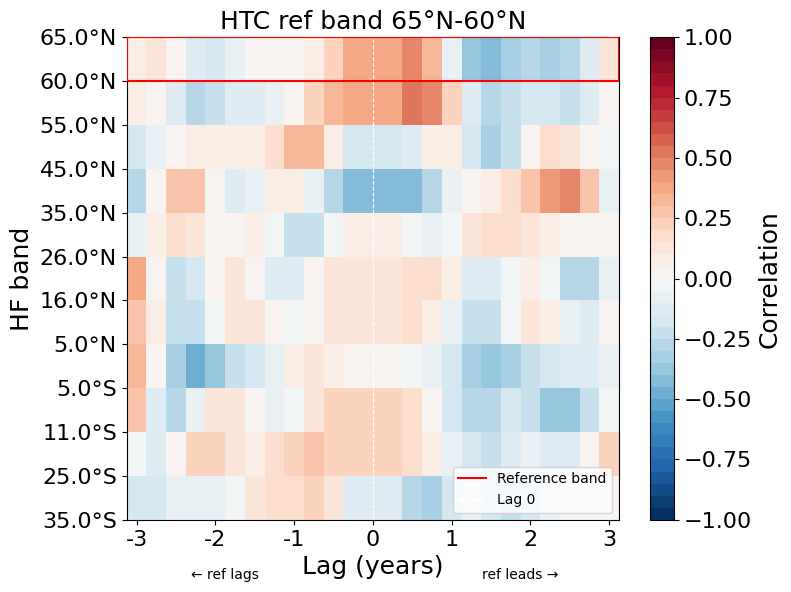

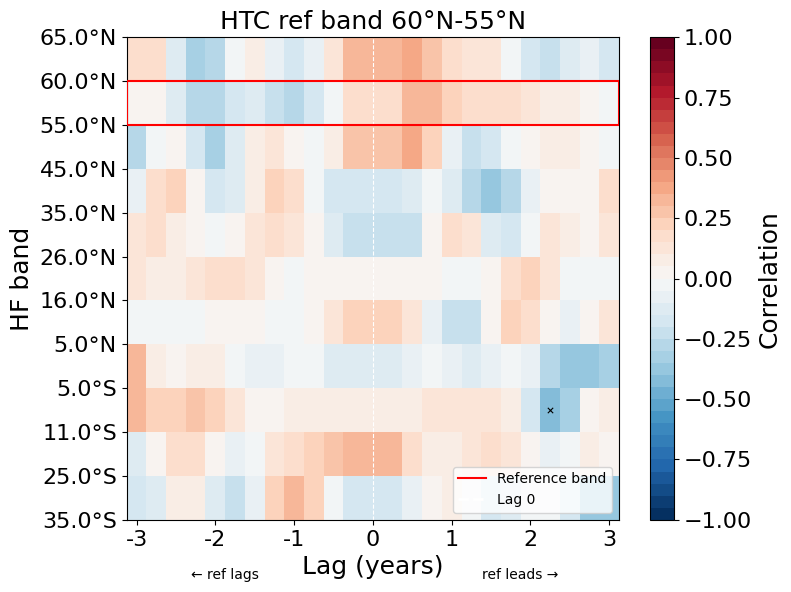

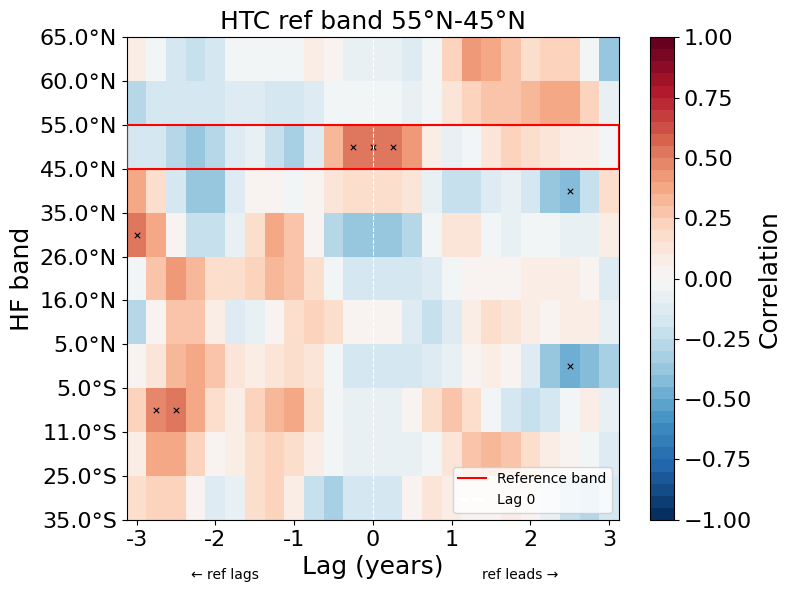

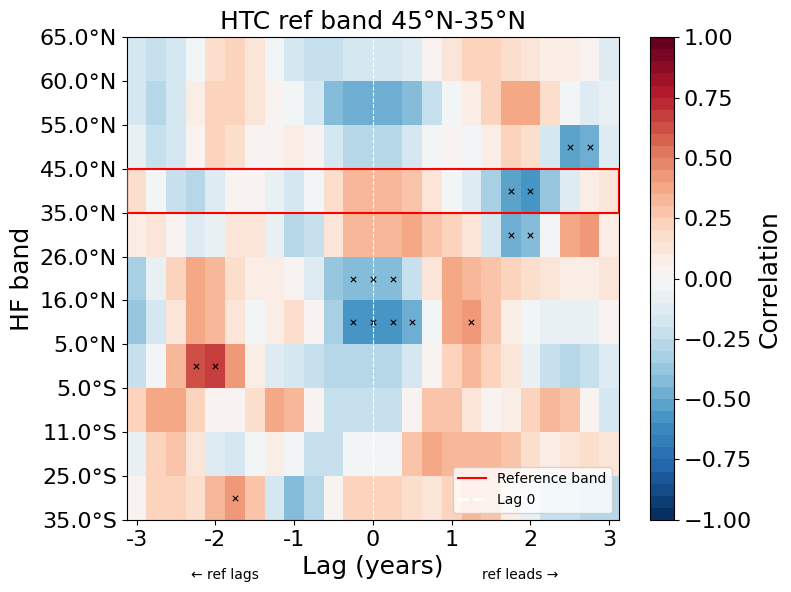

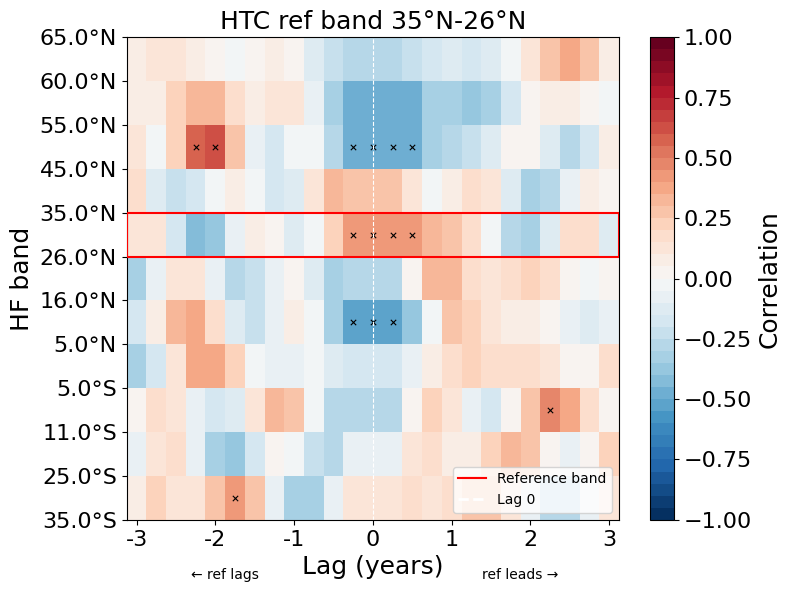

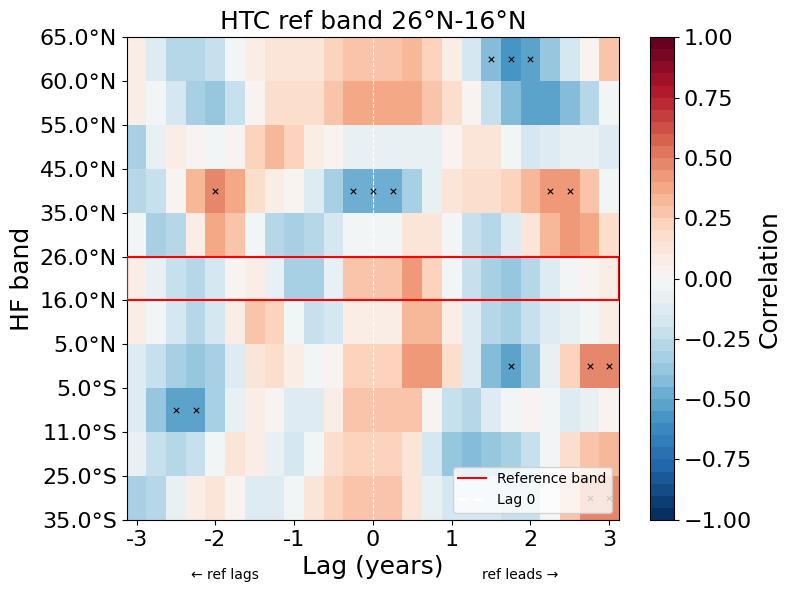

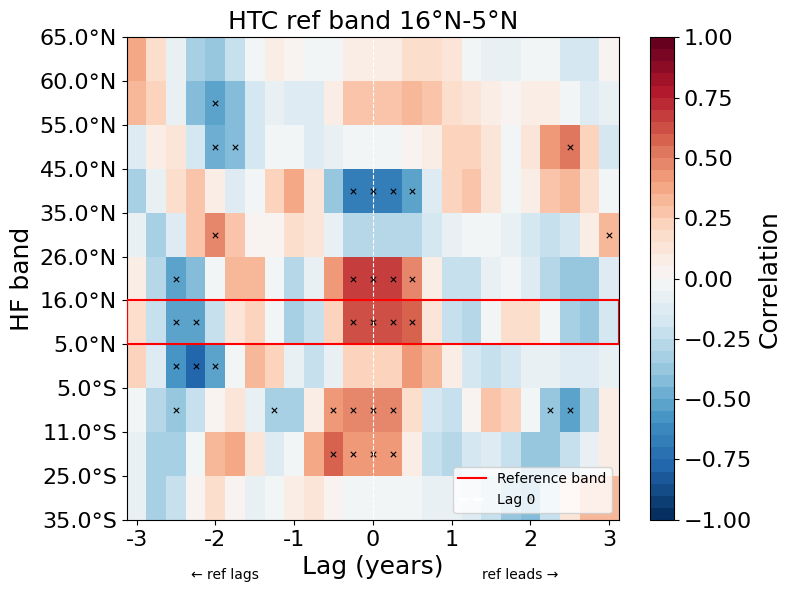

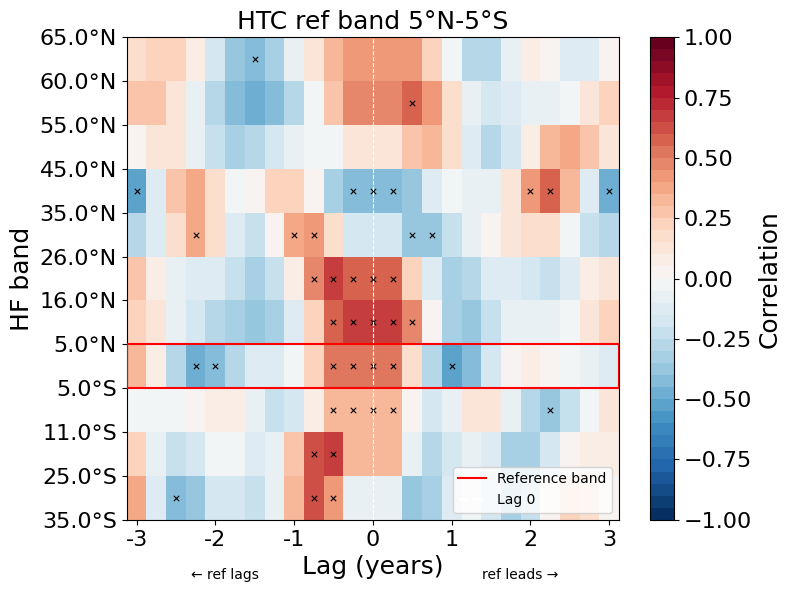

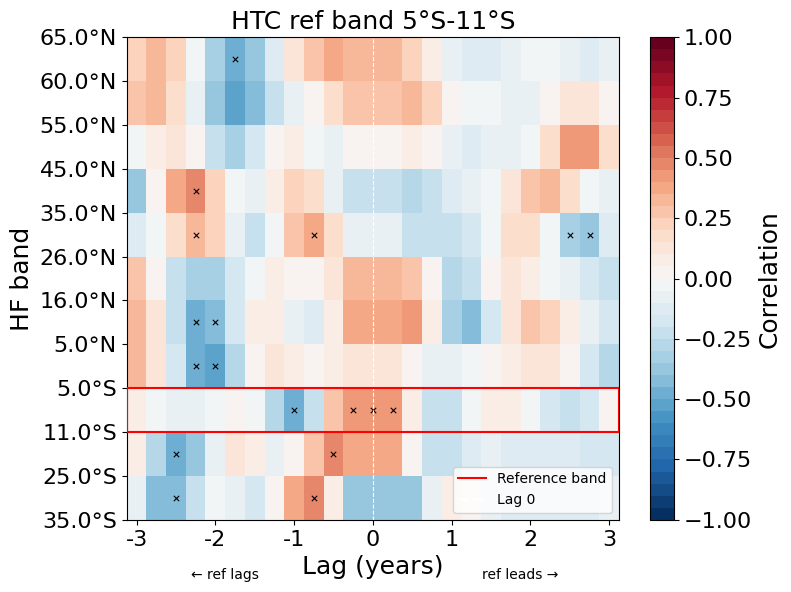

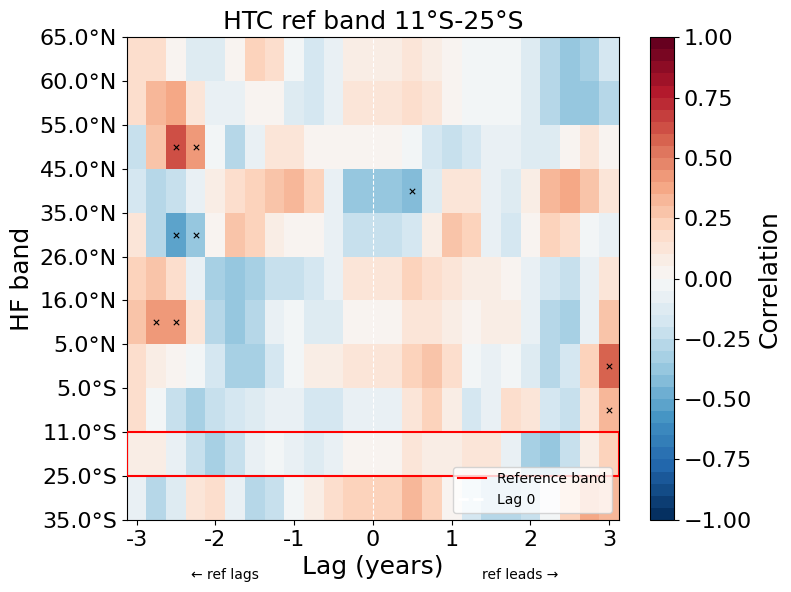

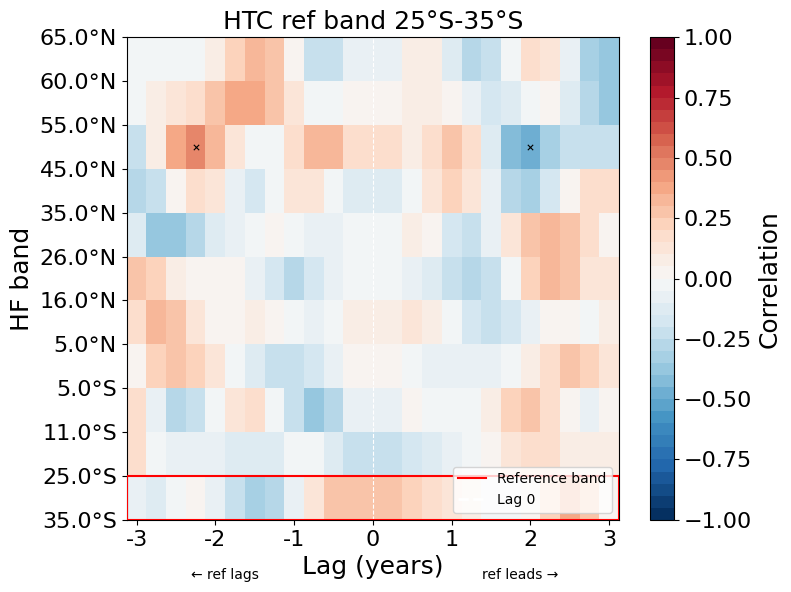

In [9]:

# plot_lead_lag_regions(htc_filtered, hf_filtered, n_effs_htc, n_effs_hf,
#                        region_labels=region_labels, cmap=cmap_corr, nlags=12)

# just one reference region, e.g. index 4 (26N-16N)
for idx in regions:
    ref_idx = idx
    plot_lead_lag_single_region(htc_filtered, hf_filtered, ref_idx=ref_idx,
                                n_effs_ref=n_effs_htc, n_effs_target=n_effs_hf,
                                region_labels=region_labels, cmap=cmap_corr, nlags=12,
                                boundary_labels=lat_labels, time_unit=time_unit)